<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 25.7 MB/s eta 0:00:00


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [3]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

--2026-09-20 18:53:52--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-09-20 18:53:52--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-09-20 18:53:52--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (

In [4]:
# Posibles bandas
os.listdir("./songs_dataset/")

['britney-spears.txt',
 'paul-simon.txt',
 'amy-winehouse.txt',
 'nirvana.txt',
 'ludacris.txt',
 'johnny-cash.txt',
 'nickelback.txt',
 'nursery_rhymes.txt',
 'leonard-cohen.txt',
 'janisjoplin.txt',
 'patti-smith.txt',
 'lady-gaga.txt',
 'bjork.txt',
 'al-green.txt',
 'radiohead.txt',
 'jimi-hendrix.txt',
 'lil-wayne.txt',
 'kanye-west.txt',
 'joni-mitchell.txt',
 'dolly-parton.txt',
 'r-kelly.txt',
 'blink-182.txt',
 'adele.txt',
 'bob-marley.txt',
 'notorious-big.txt',
 'drake.txt',
 'beatles.txt',
 'Kanye_West.txt',
 'alicia-keys.txt',
 'Lil_Wayne.txt',
 'dr-seuss.txt',
 'dj-khaled.txt',
 'missy-elliott.txt',
 'lin-manuel-miranda.txt',
 'michael-jackson.txt',
 'dickinson.txt',
 'bruce-springsteen.txt',
 'lorde.txt',
 'prince.txt',
 'cake.txt',
 'nicki-minaj.txt',
 'disney.txt',
 'eminem.txt',
 'bieber.txt',
 'rihanna.txt',
 'bob-dylan.txt',
 'notorious_big.txt',
 'bruno-mars.txt',
 'kanye.txt']

In [5]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_920/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [6]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [7]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [8]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [9]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [10]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [11]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [12]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [13]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [14]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.625
Loss after epoch 2: 65935.046875
Loss after epoch 3: 65718.328125
Loss after epoch 4: 63875.03125
Loss after epoch 5: 64160.8125
Loss after epoch 6: 64080.3125
Loss after epoch 7: 64814.96875
Loss after epoch 8: 62632.5
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58883.875
Loss after epoch 12: 57716.125
Loss after epoch 13: 56494.1875
Loss after epoch 14: 55817.5625
Loss after epoch 15: 55843.1875
Loss after epoch 16: 51722.3125
Loss after epoch 17: 49858.125
Loss after epoch 18: 49592.375
Loss after epoch 19: 48960.0


(156986, 287740)

### 4 - Ensayar

In [15]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954238295555115),
 ('sleep', 0.8665637969970703),
 ('help', 0.8439353108406067),
 ('cry', 0.8351286053657532),
 ('not', 0.8309641480445862),
 ('try', 0.8276920318603516),
 ('peace', 0.8144835233688354),
 ('little', 0.8140542507171631),
 ('twist', 0.8123894929885864),
 ('seems', 0.8079566359519958)]

In [16]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.2287309318780899),
 ('four', -0.23302660882472992),
 ('five', -0.23746736347675323),
 ('six', -0.23784852027893066),
 ('bang', -0.24833035469055176),
 ('our', -0.2553912103176117),
 ('day', -0.2689830958843231),
 ('going', -0.2692137360572815),
 ('here', -0.2699104845523834),
 ('three', -0.2839003801345825)]

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813724756240845),
 ('three', 0.9745777249336243),
 ('six', 0.9710812568664551),
 ('seven', 0.9584368467330933),
 ('two', 0.9517239332199097),
 ('sixty', 0.8990397453308105),
 ('one', 0.795121431350708),
 ('crying', 0.7946274280548096),
 ('us', 0.7740067839622498),
 ("i'm", 0.7508398294448853)]

In [18]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9433997869491577),
 ('buy', 0.9396989345550537),
 ('much', 0.9033164381980896),
 ('just', 0.8509097695350647),
 ('hide', 0.8355392813682556)]

In [19]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [20]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138305  0.05881333 -0.06370755  0.02444775 -0.20152195 -0.18612184
 -0.15284826  0.45487037 -0.04218006  0.03535983  0.13657492 -0.18520045
 -0.18126617  0.22149472 -0.3038098  -0.2397019   0.07094733 -0.05679122
 -0.05166152 -0.23843256 -0.08530398  0.19564743 -0.07679035  0.03797102
  0.07517121 -0.04826119  0.07379342  0.10396571  0.00738085 -0.22764632
 -0.04567216  0.12937427  0.27785635  0.19387512 -0.13509206  0.20856984
  0.40917465 -0.00387058 -0.10631468 -0.09056927  0.02400546 -0.0800494
  0.13400891  0.08833336 -0.01894625  0.08592407 -0.1590556   0.10259219
  0.14459157 -0.12092865 -0.27919155 -0.04061459  0.11382194  0.3136597
 -0.07410164  0.13976608  0.22791268  0.13209176 -0.01811359  0.09772693
  0.0924959  -0.14871807 -0.16348243 -0.13203168 -0.09834307  0.02714351
  0.16531163  0.26052278 -0.03259142 -0.02894571  0.11621213 -0.0697405
  0.09563474 -0.15276304  0.22071072  0.15996547  0.15890133 -0.04711402
 -0.12555073 -0.03993772 -0.10795346  0.01878977  0.07

In [21]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 1.0),
 ('babe', 0.9085158109664917),
 ('someone', 0.8886135816574097),
 ('need', 0.882800817489624),
 ('nothing', 0.8740264773368835),
 ("didn't", 0.8638384342193604),
 ("there's", 0.8526685833930969),
 ('you', 0.8456694483757019),
 ('feed', 0.8445034623146057),
 ('somebody', 0.8362801671028137)]

In [22]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085157513618469),
 ('someone', 0.8886136412620544),
 ('need', 0.8828008770942688),
 ('nothing', 0.8740264773368835),
 ("didn't", 0.8638384342193604),
 ("there's", 0.8526685833930969),
 ('you', 0.8456694483757019),
 ('feed', 0.8445034027099609),
 ('somebody', 0.8362802267074585),
 ('buy', 0.8351722359657288)]

### 5 - Visualizar agrupación de vectores

In [23]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [24]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [25]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [26]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

## Resolución Desafío

Paso 1: Obtener el corpus

In [27]:
import urllib.request

url = "https://www.gutenberg.org/cache/epub/39209/pg39209.txt"
raw_text = urllib.request.urlopen(url).read().decode("utf-8")

print("Tamaño del texto crudo:", len(raw_text), "caracteres")

Tamaño del texto crudo: 92153 caracteres


Los archivos de Gutenberg traen un encabezado y un pie legal (licencia) que no son parte del libro. Para poder continuar con el desafío los recorto.

In [28]:
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK PLATERO Y YO ***"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK PLATERO Y YO ***"

start_idx = raw_text.find(start_marker) + len(start_marker)
end_idx = raw_text.find(end_marker)

book_text = raw_text[start_idx:end_idx].strip()
print("Tamaño del libro limpio:", len(book_text), "caracteres")
print(book_text[:500])

Tamaño del libro limpio: 72520 caracteres
Produced by Chuck Greif & Víctor Moné







Juan Ramón Jiménez

PLATERO Y YO

Elegía andaluza

Esta edición reproduce el texto
de la primera, publicada en 1914.


ADVERTENCIA Á LOS HOMBRES

QUE LEAN ESTE LIBRO PARA NIÑOS


Este breve libro, en donde la alegría y la pena
son gemelas, cual las orejas de Platero, estaba
escrito para... ¡qué sé yo para quién!... para
quien escribimos los poetas líricos... Ahora que
va á los niños, no le quito ni le pongo una coma.
¡Qué b


Al inicio se observa el paratexto real del libro (créditos del transcriptor, portada, dedicatoria "Advertencia á los hombres..."), que Project Gutenberg incluye dentro de los marcadores START/END porque forma parte de la edición digitalizada. Como esas pocas líneas de créditos/portada son un puñado de palabras contra ~12.000 palabras del libro entero, se asume que no van a afectar en nada los embeddings, por lo tanto lo voy a mantener.

Paso 2: Transformo de libro a lista de documentos tokenizados.

Word2Vec calcula el contexto de una palabra dentro de cada documento. Si se mezclan dos oraciones distintas en un mismo documento el modelo puede aprender relaciones de contexto que en realidad no existen, por ejemplo: la última palabra de una oración puede "contaminar" el contexto de la primera palabra de la próxima. En consecuencia, se separa el libro en oraciones, y cada oración es una lista de tokens.

In [29]:
import re
from tensorflow.keras.preprocessing.text import text_to_word_sequence

# Separo el libro en oraciones (separador: . ! ? seguido de espacio/salto de línea)
sentences_raw = re.split(r'(?<=[.!?])\s+', book_text.replace('\r', ' ').replace('\n', ' '))
sentences_raw = [s for s in sentences_raw if len(s.strip()) > 0]

print("Cantidad de oraciones:", len(sentences_raw))
print(sentences_raw[:3])

Cantidad de oraciones: 725
['Produced by Chuck Greif & Víctor Moné                Juan Ramón Jiménez    PLATERO Y YO    Elegía andaluza    Esta edición reproduce el texto  de la primera, publicada en 1914.', 'ADVERTENCIA Á LOS HOMBRES    QUE LEAN ESTE LIBRO PARA NIÑOS      Este breve libro, en donde la alegría y la pena  son gemelas, cual las orejas de Platero, estaba  escrito para...', '¡qué sé yo para quién!...']


In [30]:
# Tokenizo cada oración (minúsculas + saca puntuación), igual que en la clase
sentence_tokens = [text_to_word_sequence(s) for s in sentences_raw]
sentence_tokens = [tokens for tokens in sentence_tokens if len(tokens) > 0]

print("Cantidad de oraciones tokenizadas:", len(sentence_tokens))
sentence_tokens[:3]

Cantidad de oraciones tokenizadas: 725


[['produced',
  'by',
  'chuck',
  'greif',
  'víctor',
  'moné',
  'juan',
  'ramón',
  'jiménez',
  'platero',
  'y',
  'yo',
  'elegía',
  'andaluza',
  'esta',
  'edición',
  'reproduce',
  'el',
  'texto',
  'de',
  'la',
  'primera',
  'publicada',
  'en',
  '1914'],
 ['advertencia',
  'á',
  'los',
  'hombres',
  'que',
  'lean',
  'este',
  'libro',
  'para',
  'niños',
  'este',
  'breve',
  'libro',
  'en',
  'donde',
  'la',
  'alegría',
  'y',
  'la',
  'pena',
  'son',
  'gemelas',
  'cual',
  'las',
  'orejas',
  'de',
  'platero',
  'estaba',
  'escrito',
  'para'],
 ['¡qué', 'sé', 'yo', 'para', 'quién']]

Paso 3: Entrenar el Word2Vec con Gensim.

Considerndo que el corpus seleccionado es mas chicos que el de la clase, se disminuye ligeramente el min_count (la frecuencia mínima para que una palabra entre al vocabulario) para no perder demasiado vocabulario.

In [31]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

class callback(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print(f'Loss after epoch {self.epoch}: {loss}')
        else:
            print(f'Loss after epoch {self.epoch}: {loss - self.loss_previous_step}')
        self.epoch += 1
        self.loss_previous_step = loss

w2v_model = Word2Vec(
    min_count=3,       # corpus chico -> bajamos el umbral vs. los 5 de la clase
    window=4,          # un poco más ancho que 2, para compensar oraciones cortas
    vector_size=100,    # menos dimensiones que 300 (tenemos poco vocabulario para justificar tantas)
    negative=15,
    workers=1,
    sg=1                # skip-gram
)

w2v_model.build_vocab(sentence_tokens)
print("Cantidad de oraciones en el corpus:", w2v_model.corpus_count)
print("Cantidad de palabras distintas en el vocabulario:", len(w2v_model.wv.index_to_key))

Cantidad de oraciones en el corpus: 725
Cantidad de palabras distintas en el vocabulario: 669


In [32]:
w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=30,          # más épocas que la clase (20), porque el corpus es chico
    compute_loss=True,
    callbacks=[callback()]
)

Loss after epoch 0: 148953.0
Loss after epoch 1: 81256.453125
Loss after epoch 2: 78024.796875
Loss after epoch 3: 77917.40625
Loss after epoch 4: 77184.96875
Loss after epoch 5: 77208.1875
Loss after epoch 6: 78064.4375
Loss after epoch 7: 77445.625
Loss after epoch 8: 77584.375
Loss after epoch 9: 77559.3125
Loss after epoch 10: 79304.8125
Loss after epoch 11: 78844.125
Loss after epoch 12: 77957.625
Loss after epoch 13: 78177.625
Loss after epoch 14: 77019.625
Loss after epoch 15: 76274.375
Loss after epoch 16: 75797.5
Loss after epoch 17: 76622.5
Loss after epoch 18: 74812.0
Loss after epoch 19: 72789.25
Loss after epoch 20: 74321.125
Loss after epoch 21: 74208.75
Loss after epoch 22: 73243.25
Loss after epoch 23: 72246.5
Loss after epoch 24: 71978.625
Loss after epoch 25: 72085.25
Loss after epoch 26: 64412.75
Loss after epoch 27: 55897.0
Loss after epoch 28: 56764.5
Loss after epoch 29: 55957.0


(164250, 368910)

Paso 4: Explorar los embeddings

In [33]:
# Palabras que más se relacionan con "platero" (protagonista, el burro)
w2v_model.wv.most_similar(positive=["platero"], topn=10)

[('ir', 0.949623167514801),
 ('despacio', 0.940147340297699),
 ('puedes', 0.9372828006744385),
 ('comer', 0.934358537197113),
 ('vamos', 0.9339028596878052),
 ('muerte', 0.9248262643814087),
 ('nostalgia', 0.9154009819030762),
 ('te', 0.9123603105545044),
 ('pájaro', 0.9106701612472534),
 ('hemos', 0.9099149703979492)]

No se observan sustantivos relacionados por "significado", sino verbos y palabras que acompañan al narrador cuando le habla directamente a Platero ("vamos, Platero", "come", "anda despacio", "Platero, tú nos ves..."). Esto tiene sentido ya que en el libro "Platero" aparece constantemente en oraciones cortas tipo vocativo, así que el contexto que rodea a esa palabra está dominado por esas fórmulas, no por descripciones físicas del burro.

También aparecen "muerte" y "nostalgia". Esto es coherente con los capítulos finales del libro (Platero muere).

In [34]:
# Palabra descriptiva (adjetivo físico)
w2v_model.wv.most_similar(positive=["blanco"], topn=10)

[('malva', 0.9533578157424927),
 ('gris', 0.9471273422241211),
 ('poniente', 0.9456145167350769),
 ('ardiente', 0.9422851800918579),
 ('cargado', 0.9393566250801086),
 ('esplendor', 0.9386716485023499),
 ('humo', 0.9366341829299927),
 ('sueño', 0.9326862096786499),
 ('limpio', 0.9324811100959778),
 ('fuera', 0.9312032461166382)]

Agrupa con otros colores (malva, gris) y con vocabulario de atardecer/cielo (poniente, ardiente, esplendor, humo). Esto tiene mucho sentido ya que en el libro hay capítulos enteros de descripciones de cielos y ocasos donde los colores se mezclan constantemente en la misma oración describiendo la luz del atardecer. El modelo capturó que "blanco" comparte contexto con esa paleta cromática-crepuscular, no con objetos blancos en general.

In [35]:
# Palabra de paisaje
w2v_model.wv.most_similar(positive=["tarde"], topn=10)

[('sube', 0.9046032428741455),
 ('amarilla', 0.8865240812301636),
 ('fuente', 0.8789147138595581),
 ('entra', 0.8782032132148743),
 ('iglesia', 0.8751488327980042),
 ('caída', 0.874401867389679),
 ('última', 0.8723880052566528),
 ('vuelta', 0.8720871806144714),
 ('chiquilla', 0.8712846636772156),
 ('dura', 0.8702226877212524)]

Se observa una mezcla más heterogénea. Por un lado paisaje/luz (amarilla, caída, sube), por otro lugares del pueblo (fuente, iglesia) y personajes (chiquilla). Esto también es coherente ya que "tarde" en el libro casi siempre aparece en escenas donde el narrador y Platero recorren el pueblo durante el atardecer. El modelo mezcló lugar + momento del día porque en el texto co-ocurren todo el tiempo.

In [39]:
# Palabras que MENOS se relacionan con "platero"
w2v_model.wv.most_similar(negative=["platero"], topn=10)

[('oro', -0.33159738779067993),
 ('azul', -0.3488844931125641),
 ('viento', -0.35758861899375916),
 ('allá', -0.3649319112300873),
 ('flor', -0.36647725105285645),
 ('luna', -0.3733779191970825),
 ('más', -0.38095539808273315),
 ('sobre', -0.39087724685668945),
 ('estrellas', -0.3989968001842499),
 ('noche', -0.42518770694732666)]

Los valores de similitud son negativos (entre -0.33 y -0.42, contra los ~0.9 que veías con positive), y las palabras que salen son en realidad vocabulario de paisaje/naturaleza (oro, azul, viento, flor, luna, estrellas, noche), es decir, prácticamente el mismo campo semántico que agrupaba con "blanco" y "tarde" antes.

Podemos confirmar que "menos similar" en Word2Vec no significa "antónimo" ni "sin relación temática". Matemáticamente es la dirección más opuesta en el espacio vectorial a "platero". El vector de "platero" quedó dominado por el contexto narrativo/vocativo (verbos, "mira", "vamos"), así que lo más alejado de eso termina siendo, casi por descarte, el vocabulario descriptivo de paisaje. Esto no implica que "oro" u "azul" tengan un significado opuesto a Platero, sino que comparten poquísimo contexto directo con él en el texto.

Paso 5: Reducir a 2D y graficar.

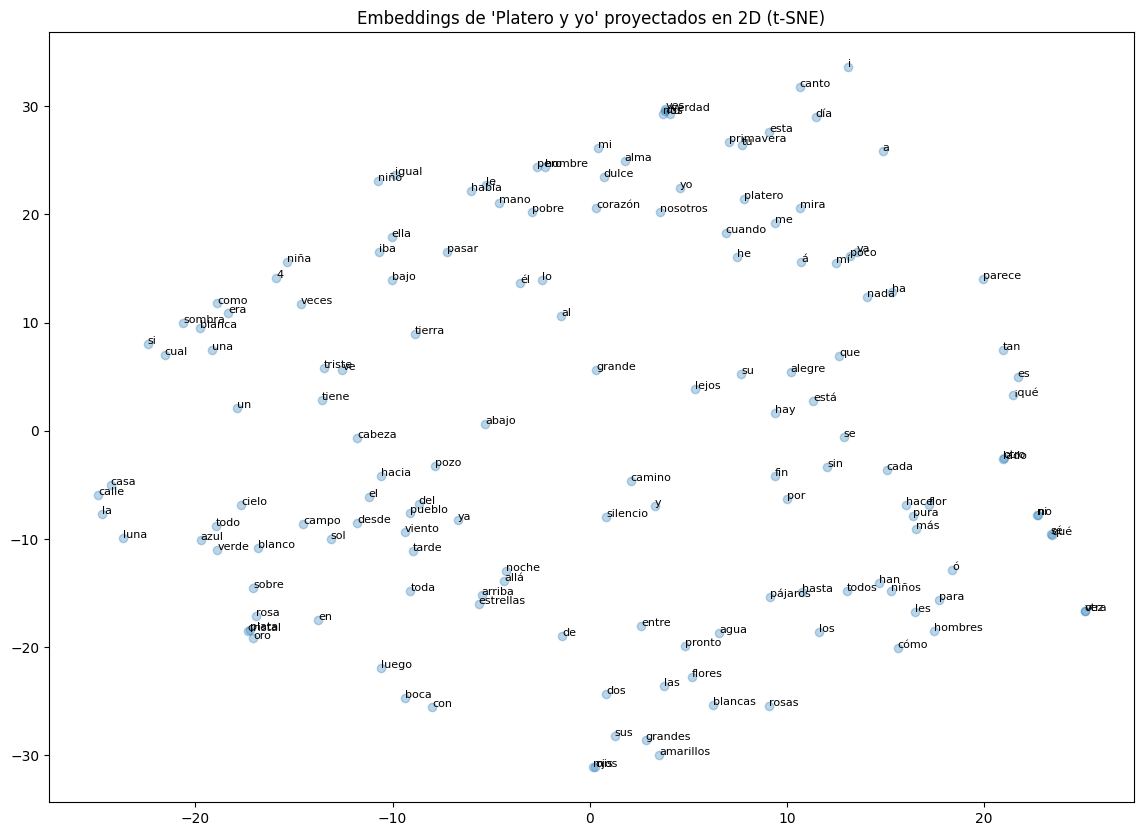

In [36]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

def reduce_dimensions(model, num_dimensions=2):
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)
    tsne = TSNE(n_components=num_dimensions, random_state=0, perplexity=30)
    vectors = tsne.fit_transform(vectors)
    return vectors, labels

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS = 150

plt.figure(figsize=(14, 10))
plt.scatter(vecs[:MAX_WORDS, 0], vecs[:MAX_WORDS, 1], alpha=0.3)
for i in range(min(MAX_WORDS, len(labels))):
    plt.annotate(labels[i], (vecs[i, 0], vecs[i, 1]), fontsize=8)
plt.title("Embeddings de 'Platero y yo' proyectados en 2D (t-SNE)")
plt.show()

Clusters de vocabulario identificados:

+ Pueblo/paisaje (zona izquierda, x≈-20 a -10, y≈-10 a 5): casa, calle, cielo, azul, verde, blanco, luna, sol, campo, pueblo, viento, tarde, silencio, camino, sombra. Es el cluster más grande y compacto: es el vocabulario descriptivo que domina el libro entero (Moguer, el pueblo, sus calles, el clima).
+ Cielo nocturno (x≈-5, y≈-13 a -16): noche, allá, arriba, estrellas. Un cluster chico pero muy limpio.
+ Flores y colores cálidos (x≈5-12, y≈-20 a -26): rosas, blancas, flores, amarillos, grandes. Otro cluster limpio, separado del cluster "pueblo".
+ Metales/colores preciosos (x≈-17, y≈-17 a -19): rosa, plata, oro. Muy pegados entre sí. Es coherente con que en el libro estas palabras aparecen juntas constantemente describiendo luces y reflejos ("cristal de oro... cristal de plata").
+ Gente/personajes (x≈15-20, y≈-10 a 0): niños, hombres, pájaro, todos.

Paso 6: Test de analogias

In [37]:
# platero - burro + perro ≈ ? (¿se acerca a "diana", la perra?)
w2v_model.wv.most_similar(positive=["platero", "perro"], negative=["burro"], topn=5)

[('miraba', 0.9045419096946716),
 ('moguer', 0.8887751698493958),
 ('elegía', 0.8862586617469788),
 ('muerte', 0.8850115537643433),
 ('descripción', 0.8844050168991089)]

In [38]:
# Otra: noche - luna + sol ≈ ?  (si aprendió la oposición día/noche)
w2v_model.wv.most_similar(positive=["noche", "sol"], negative=["luna"], topn=5)

[('jardín', 0.8663687705993652),
 ('clara', 0.827811598777771),
 ('flores', 0.8201773762702942),
 ('fuera', 0.8070244193077087),
 ('malva', 0.7969036102294922)]

Ninguna de las dos analogías dio el resultado "esperado" (diana no aparece en la primera, y la segunda no da vocabulario de "día/luz solar" limpio). Esto se debe a que los tests de analogías clásicos necesitan corpus enormes para funcionar bien, porque dependen de que la geometría del espacio vectorial sea muy regular y un corpus de ~12.000 palabras no puede garantizarlo.

Mas alla de eso, hay un matiz interesante en la segunda: aparecen clara y malva, que sí son palabras de luz/color asociadas al alba y al atardecer respectivamente. No es una analogía "correcta" en sentido estricto, pero tampoco es ruido puro: el modelo se movió hacia vocabulario de luminosidad, que es el campo semántico correcto, aunque no aisló específicamente "día vs. noche".
